# 08. Diagnóstico probabilístico y estabilidad económica

En el notebook 07 comparamos tres políticas sobre las mismas transacciones. BMR obtuvo el menor costo realizado en los seis escenarios hipotéticos, pero ese resultado no demuestra que las probabilidades sean fiables en todos los grupos ni que el ahorro se distribuya de manera uniforme en el tiempo.

En esta etapa examinamos ambas preguntas utilizando las probabilidades del 06 y las acciones del 07. No entrenamos modelos, no cambiamos el calibrador y no seleccionamos Ca. La validación posterior continúa siendo desarrollo; el bloque final no se puntúa.

## 1. Alcance y reglas del diagnóstico

Trabajamos únicamente con las 42.047 operaciones de validación posterior. Verificamos los hashes de las fuentes y artefactos previos antes de leer los scores y las acciones; no necesitamos cargar modelos serializados.

Antes de construir las tablas fijamos estas agrupaciones descriptivas:

- Monto: [0,50), [50,100), [100,250), [250,500), [500,1000), [1000,∞), en unidades del dataset.
- Probabilidad calibrada: [0,0,01), [0,01,0,05), [0,05,0,10), [0,10,0,25), [0,25,0,50), [0,50,1]. Los valores de frontera pertenecen al intervalo que comienza allí; el último incluye 1.
- Tiempo: cuatro intervalos de igual duración dentro de esta ventana, no cuatro conjuntos de igual número de filas. TransactionDT mide tiempo relativo; no asignamos fechas calendario.

Estos cortes no son umbrales nuevos de clasificación o intervención. Conservamos el corte clasificatorio 0,5 y los seis Ca ilustrativos del 07. Reportamos conteos de operaciones y fraudes, incluidos grupos vacíos, sin intervalos inferenciales que supongan independencia entre transacciones.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from fraud_cost.paths import PROJECT_ROOT
from fraud_cost.diagnostics import (
    verified_diagnostic_inputs, conditional_calibration, boundary_diagnostic,
    temporal_diagnostic, diagnostic_figures, save_diagnostics,
)

scores, actions, economic_config = verified_diagnostic_inputs(PROJECT_ROOT)
CA_GRID = tuple(economic_config['ca_grid'])
EXAMPLE_CA = 10.0  # Caso ilustrativo del 07; no es un costo operativo aprobado.
print(f'Validación posterior: {len(scores):,} operaciones; {int(scores.isFraud.sum()):,} fraudes.')
print('Probabilidades y acciones verificadas. Sin ajustes nuevos ni evaluación de test.')

Validación posterior: 42,047 operaciones; 1,517 fraudes.
Probabilidades y acciones verificadas. Sin ajustes nuevos ni evaluación de test.


## 2. Probabilidad, monto y calibración condicional

Una probabilidad de 0,10 significa que esperamos aproximadamente un 10% de fraudes entre operaciones comparables con esa predicción; no significa que una transacción individual sea «10% fraudulenta». Contrastamos la probabilidad media del grupo con su proporción observada de fraudes.

Definimos el residuo como **tasa observada menos probabilidad media**: positivo indica subestimación en ese grupo; negativo, sobreestimación. No deducimos calibración perfecta ni ausencia de dependencia a partir de una coincidencia agregada.

También contrastamos ΣpᵢAᵢ con ΣyᵢAᵢ. La primera es el monto fraudulento esperado bajo el modelo; la segunda, el monto fraudulento observado. Ambas incluyen todas las operaciones: todavía no son el costo de una política. Si interviniéramos, aparecería Ca y cambiaría el monto fraudulento aprobado.

Los grupos de riesgo se construyen con la probabilidad calibrada y son los mismos para evaluar la original. Así no comparamos poblaciones distintas por cambiar de calibrador. Exportamos además el cruce monto × riesgo; los grupos pequeños deben leerse con sus conteos, no como estimaciones robustas.

In [2]:
calibration = conditional_calibration(scores)
summary_columns = ['amount_band', 'risk_band', 'probabilities', 'rows', 'frauds',
                   'observed_rate', 'mean_probability', 'observed_minus_predicted_rate',
                   'fraud_amount_observed', 'fraud_amount_expected']
display(calibration.loc[calibration.grouping.eq('amount'), summary_columns].round(6))
display(calibration.loc[calibration.grouping.eq('risk') &
                        calibration.probabilities.eq('probability_calibrated'), summary_columns].round(6))

crossed = calibration.loc[calibration.grouping.eq('amount_risk') &
                          calibration.probabilities.eq('probability_calibrated')].copy()
print(f'Cruce de 36 grupos: {(crossed.rows == 0).sum()} vacíos; '
      f'{((crossed.rows > 0) & (crossed.rows < 100)).sum()} con menos de 100 operaciones.')
# Mostramos los seis mayores residuos absolutos de monto, no una selección de modelos.
order = crossed.observed_minus_expected_fraud_amount.abs().sort_values(ascending=False).index
display(crossed.loc[order[:6], summary_columns + ['observed_minus_expected_fraud_amount']].round(6))

,amount_band,risk_band,probabilities,rows,frauds,observed_rate,mean_probability,observed_minus_predicted_rate,fraud_amount_observed,fraud_amount_expected
0,"[0, 50)",all,probability_raw,13918,513,0.036859,0.036075,0.000783,14055.747,13692.472066
1,"[0, 50)",all,probability_calibrated,13918,513,0.036859,0.034624,0.002235,14055.747,13065.571320
2,"[50, 100)",all,probability_raw,11495,355,0.030883,0.025059,0.005824,24520.048,19843.115316
3,"[50, 100)",all,probability_calibrated,11495,355,0.030883,0.023560,0.007323,24520.048,18664.248788
4,"[100, 250)",all,probability_raw,12075,395,0.032712,0.031200,0.001513,61271.060,57391.270725
5,"[100, 250)",all,probability_calibrated,12075,395,0.032712,0.029380,0.003332,61271.060,54098.807322
6,"[250, 500)",all,probability_raw,2742,125,0.045587,0.042501,0.003086,43417.257,41155.126525
7,"[250, 500)",all,probability_calibrated,2742,125,0.045587,0.040008,0.005579,43417.257,38817.038058
8,"[500, 1000)",all,probability_raw,1209,116,0.095947,0.066736,0.029211,88800.310,58076.354397
9,"[500, 1000)",all,probability_calibrated,1209,116,0.095947,0.063769,0.032178,88800.310,55668.022995


,amount_band,risk_band,probabilities,rows,frauds,observed_rate,mean_probability,observed_minus_predicted_rate,fraud_amount_observed,fraud_amount_expected
13,all,"[0, 0.01)",probability_calibrated,23604,105,0.004448,0.005070,-0.000622,10519.854,14393.537745
15,all,"[0.01, 0.05)",probability_calibrated,14381,388,0.026980,0.020402,0.006578,54954.044,50086.145160
17,all,"[0.05, 0.1)",probability_calibrated,1897,203,0.107011,0.069091,0.037920,42923.665,24313.847201
19,all,"[0.1, 0.25)",probability_calibrated,1218,237,0.194581,0.151391,0.043190,51259.912,40336.788947
21,all,"[0.25, 0.5)",probability_calibrated,384,161,0.419271,0.343815,0.075456,40411.040,33905.182777
23,all,"[0.5, 1]",probability_calibrated,563,423,0.751332,0.810802,-0.059470,54468.297,51481.644492


Cruce de 36 grupos: 0 vacíos; 11 con menos de 100 operaciones.


,amount_band,risk_band,probabilities,rows,frauds,observed_rate,mean_probability,observed_minus_predicted_rate,fraud_amount_observed,fraud_amount_expected,observed_minus_expected_fraud_amount
77,"[500, 1000)","[0.05, 0.1)",probability_calibrated,113,26,0.230088,0.069207,0.160881,16912.970,5001.363149,11911.606851
81,"[500, 1000)","[0.25, 0.5)",probability_calibrated,54,29,0.537037,0.334844,0.202193,25900.000,14521.201818,11378.798182
79,"[500, 1000)","[0.1, 0.25)",probability_calibrated,98,22,0.224490,0.148682,0.075808,15658.000,9512.105864,6145.894136
93,"[1000, inf)","[0.25, 0.5)",probability_calibrated,16,1,0.062500,0.348977,-0.286477,1224.000,7004.081873,-5780.081873
53,"[100, 250)","[0.05, 0.1)",probability_calibrated,612,60,0.098039,0.069789,0.028250,10160.179,6479.049208,3681.129792
51,"[100, 250)","[0.01, 0.05)",probability_calibrated,4423,113,0.025548,0.020708,0.004841,17201.796,13800.438659,3401.357341


## 3. Proximidad a la frontera económica

BMR interviene cuando pᵢAᵢ > Ca y aprueba en empate. Para describir la proximidad calculamos qᵢ = pᵢAᵢ/Ca, usando Ca positivos. q=1 es la frontera; q<1 favorece aprobar; q>1 favorece intervenir.

Fijamos las bandas [0,0,5), [0,5,0,9), [0,9,1,1), [1,1,2) y [2,∞). Llamamos «cercana» a [0,9,1,1): es una convención descriptiva de ±10% del costo, **no un margen de error estadístico** ni un certificado de sensibilidad. Si Aᵢ≤Ca, ninguna probabilidad válida permite una intervención estrictamente más barata; tampoco dividimos por montos cero.

Contamos las acciones que cambian entre probabilidades originales y calibradas dentro de cada banda definida con la calibrada. Descomponemos su costo en administración y fraude aprobado. Un cambio puede quedar fuera de la banda cercana; no afirmamos que todas las decisiones sensibles estén allí.

In [3]:
boundary = boundary_diagnostic(scores, ca_grid=CA_GRID)
near_columns = ['administrative_cost_ca', 'rows', 'frauds', 'population_fraction',
                'amount_le_ca_count', 'calibrated_block_count', 'actions_changed',
                'additional_interventions', 'fewer_interventions', 'calibrated_minus_raw_cost']
display(boundary.loc[boundary.near_boundary, near_columns].round(6))
display(boundary.loc[boundary.administrative_cost_ca.eq(EXAMPLE_CA),
                     ['margin_band'] + near_columns[1:] +
                     ['administrative_cost_delta', 'missed_fraud_amount_delta']].round(6))

,administrative_cost_ca,rows,frauds,population_fraction,amount_le_ca_count,calibrated_block_count,actions_changed,additional_interventions,fewer_interventions,calibrated_minus_raw_cost
2,1.0,1803,28,0.042881,0,840,953,0,953,-303.895
7,5.0,858,30,0.020406,0,382,416,0,416,-445.052
12,10.0,559,52,0.013295,3,265,237,0,237,95.097
17,20.0,339,52,0.008062,2,154,123,1,122,111.363
22,50.0,177,59,0.004210,8,77,47,1,46,-387.634
27,100.0,89,41,0.002117,6,43,10,0,10,329.000


,margin_band,rows,frauds,population_fraction,amount_le_ca_count,calibrated_block_count,actions_changed,additional_interventions,fewer_interventions,calibrated_minus_raw_cost,administrative_cost_delta,missed_fraud_amount_delta
10,"[0, 0.5)",36206,530,0.861084,663,0,0,0,0,0.000,0.0,0.000
11,"[0.5, 0.9)",2025,143,0.048160,28,0,5,0,5,-50.000,-50.0,0.000
12,"[0.9, 1.1)",559,52,0.013295,3,265,237,0,237,95.097,-2370.0,2465.097
13,"[1.1, 2)",1314,188,0.031251,0,1314,0,0,0,0.000,0.0,0.000
14,"[2, inf)",1943,604,0.046210,0,1943,0,0,0,0.000,0.0,0.000


## 4. Estabilidad dentro de la ventana posterior

Aplicamos las acciones ya guardadas a cuatro subperiodos de igual duración. No reajustamos el predictor, la calibración, los árboles ni el historial entre subperiodos. Operaciones simultáneas permanecen en el mismo intervalo; el último incluye el máximo TransactionDT.

Reportamos población, prevalencia, monto fraudulento y probabilidad media para interpretar los costos. Como los tamaños y montos cambian, mostramos costo total y costo por transacción. Una diferencia entre periodos puede obedecer a su composición, a errores del modelo o a ambos; no identifica por sí sola un cambio causal de la distribución.

Los costos totales y sus componentes son aditivos. Las tasas, porcentajes de ahorro y la referencia min(aprobar todo, intervenir todo) **no deben sumarse**: recalculamos esa referencia en cada periodo y conservamos la del 07 para la ventana completa. La ventaja esperada de BMR sigue siendo por construcción bajo pᵢ; aquí importa contrastarla con el costo realizado.

In [4]:
populations, temporal = temporal_diagnostic(scores, actions, ca_grid=CA_GRID)
population_columns = ['period', 'relative_day_start', 'relative_day_end', 'rows', 'frauds',
                      'observed_rate', 'mean_probability', 'fraud_amount_observed', 'fraud_amount_expected']
display(populations.loc[populations.probabilities.eq('probability_calibrated'), population_columns].round(6))
display(temporal.loc[temporal.administrative_cost_ca.eq(EXAMPLE_CA),
                     ['period', 'strategy', 'rows', 'cost_total_proxy', 'cost_per_transaction_proxy',
                      'fraud_recall', 'legitimate_block_rate', 'savings_fraction_vs_reference']].round(6))

bmr_by_period = temporal.loc[temporal.strategy.eq('bmr')].copy()
bmr_by_period['bmr_minus_fixed_per_transaction'] = -bmr_by_period.savings_vs_fixed_proxy / bmr_by_period.rows
display(bmr_by_period.pivot(index='administrative_cost_ca', columns='period',
                           values='bmr_minus_fixed_per_transaction').round(6))

,period,relative_day_start,relative_day_end,rows,frauds,observed_rate,mean_probability,fraud_amount_observed,fraud_amount_expected
1,1,0.000000,3.973247,10888,447,0.041054,0.034462,75779.332,59297.568812
3,2,3.973247,7.946493,10419,335,0.032153,0.027733,61583.477,51034.625429
5,3,7.946493,11.919740,10783,402,0.037281,0.032471,70206.314,58281.756827
7,4,11.919740,15.892986,9957,333,0.033444,0.030404,46967.689,45903.195255


,period,strategy,rows,cost_total_proxy,cost_per_transaction_proxy,fraud_recall,legitimate_block_rate,savings_fraction_vs_reference
6,1,fixed_0_5,10888,63784.291,5.858219,0.293065,0.004214,0.158289
7,1,bmr,10888,23195.006,2.130328,0.570470,0.071162,0.693914
8,1,cost_sensitive_tree,10888,35382.636,3.249691,0.407159,0.080644,0.533083
24,2,fixed_0_5,10419,44546.625,4.275518,0.268657,0.001587,0.276646
25,2,bmr,10419,20985.287,2.014136,0.519403,0.060690,0.659238
26,2,cost_sensitive_tree,10419,25664.054,2.463197,0.417910,0.065450,0.583264
42,3,fixed_0_5,10783,59137.045,5.484285,0.263682,0.004528,0.157668
43,3,bmr,10783,23034.227,2.136161,0.524876,0.071669,0.671907
44,3,cost_sensitive_tree,10783,31787.224,2.947902,0.388060,0.077257,0.547231
60,4,fixed_0_5,9957,38230.554,3.839566,0.288288,0.003429,0.186024


period,1,2,3,4
administrative_cost_ca,,,,
1.0,-5.082096,-3.596583,-4.776539,-3.149461
5.0,-4.143253,-2.809147,-3.833093,-2.215144
10.0,-3.727892,-2.261382,-3.348124,-1.711860
20.0,-3.157456,-1.697072,-2.813658,-1.021051
50.0,-2.304262,-1.130356,-1.802020,-0.676639
100.0,-2.159315,-0.985061,-1.477323,-0.840971


## 5. Evidencia que conservamos

Exportamos cuatro tablas agregadas: calibración por grupos, frontera BMR, población de subperiodos y costos de subperiodos. Guardamos dos figuras y un registro de configuración con hashes. No generamos nuevos modelos ni otro archivo por transacción; reutilizamos los artefactos locales del 06/07.

La lógica de validación y agrupación vive en `src/fraud_cost/diagnostics.py`. Las celdas permiten recorrer el razonamiento y examinar resultados sin duplicar la matriz de costos.

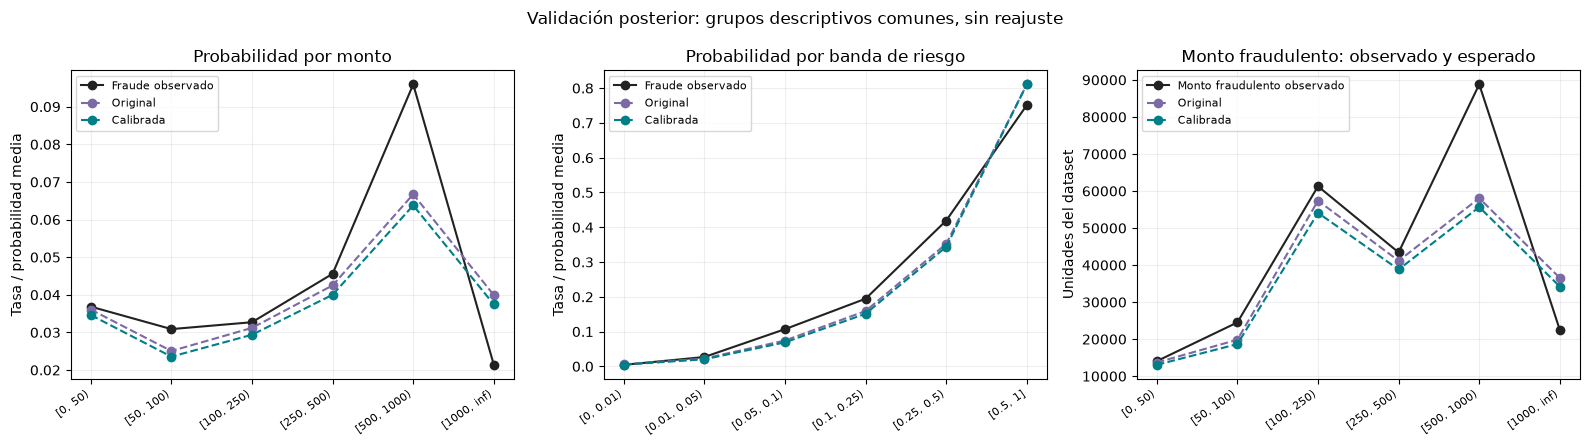

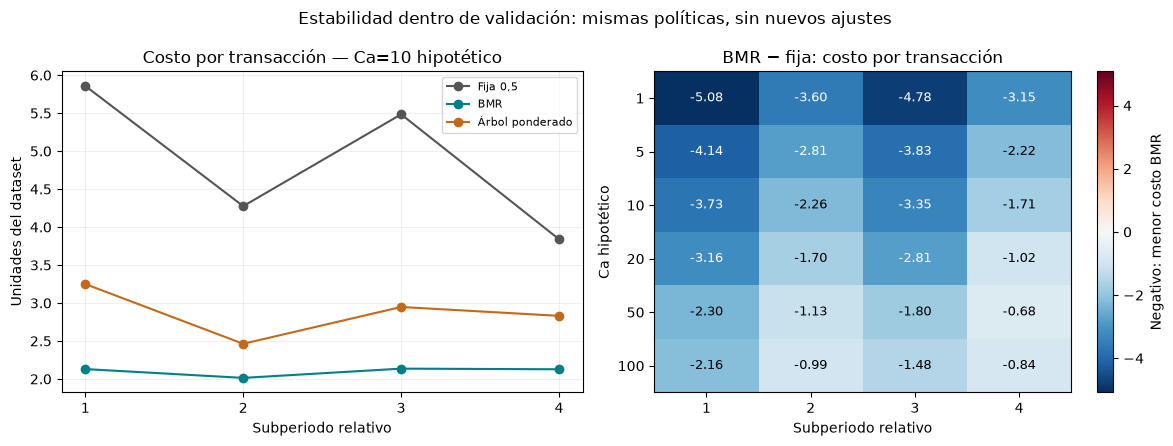

Exportadas cuatro tablas, dos figuras y la configuración del diagnóstico 08.


In [5]:
figures = diagnostic_figures(calibration, temporal, example_ca=EXAMPLE_CA)
for figure in figures.values():
    display(figure)
record = save_diagnostics(PROJECT_ROOT, calibration, boundary, populations, temporal,
                          figures, ca_grid=CA_GRID)
for figure in figures.values():
    plt.close(figure)
assert record['test_evaluated'] is False and record['models_refitted'] is False
print('Exportadas cuatro tablas, dos figuras y la configuración del diagnóstico 08.')

## 6. Lectura de los resultados y decisiones pendientes

Encontramos subestimación en cinco de las seis bandas de monto. En [500,1000), las 1.209 operaciones contienen 116 fraudes: su frecuencia es 9,59%, frente a una probabilidad calibrada media de 6,38%. El monto fraudulento observado es 88.800,310, frente a 55.668,023 esperado. En [1000,∞) el signo se invierte: 13 fraudes entre 608 operaciones; no asumimos que la probabilidad de fraude crece siempre con el monto.

El cruce monto × riesgo tiene 11 grupos con menos de 100 operaciones. Por ejemplo, [500,1000) y p∈[0,05,0,10) contiene 113 operaciones y 26 fraudes: 23,01% observado frente a 6,92% predicho. Es una señal descriptiva relevante, no una estimación confirmada de otro conjunto de datos. La suma global pᵢAᵢ calibrada es 214.517,146, inferior al monto fraudulento observado de 254.536,812; esto no es todavía el costo realizado BMR.

Con Ca=10 hay 559 operaciones cercanas a la frontera (1,33% de la ventana), con 52 fraudes. En esa banda cambian 237 de las 242 acciones modificadas por la calibración. Su delta de costo es +95,097; las cinco retiradas fuera de la banda ahorran 50,000, dando el delta global +45,097 del 07. La proximidad ayuda a localizar el efecto, pero no garantiza beneficio al recalibrar.

BMR cuesta menos que la política fija en los cuatro subperiodos y los seis Ca. En Ca=10 su costo por transacción varía entre 2,014 y 2,136 unidades. Sin embargo, no gana siempre frente al árbol: en el cuarto subperiodo con Ca=100, el árbol cuesta 39.775,411 y BMR 41.467,007. BMR conserva el mínimo esperado bajo sus probabilidades, pero no necesariamente el mínimo realizado en cada segmento.

Los detalles y las limitaciones están en `docs/08_diagnostico_y_estabilidad.md`. No seleccionamos otro calibrador ni modificamos las reglas con estas etiquetas. Antes de la evaluación final debemos discutir estos residuos, acordar los escenarios y unidades de Ca y congelar el protocolo.